In [29]:
import warnings
warnings.filterwarnings(action='ignore')

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('train.csv', usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])
df.head(5)

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [32]:
print('Total no. of Missing values.')
print('-'*25)
df.isnull().sum()

Total no. of Missing values.
-------------------------


FireplaceQu    690
GarageQual      81
SalePrice        0
dtype: int64

In [33]:
print('Avg. Missing values.')
print('-'*25)
df.isnull().mean()*100

Avg. Missing values.
-------------------------


FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [34]:
df['GarageQual'].unique()

array(['TA', 'Fa', 'Gd', nan, 'Ex', 'Po'], dtype=object)

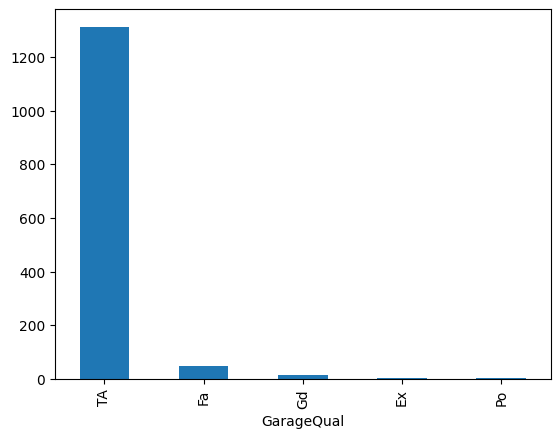

In [35]:
df['GarageQual'].value_counts().plot.bar()
plt.show()

In [36]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

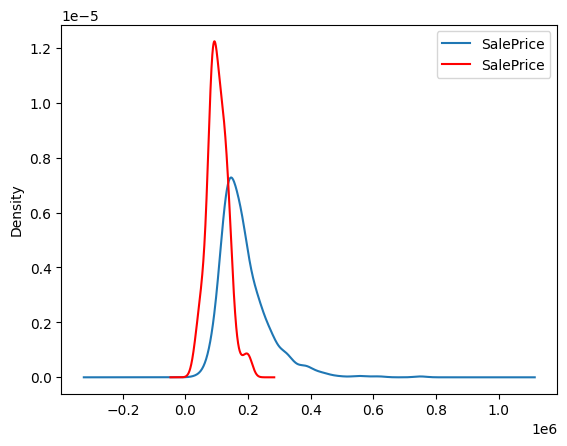

In [37]:
df.loc[df['GarageQual'] == 'TA', 'SalePrice'].plot.density()
df.loc[df['GarageQual'].isnull(), 'SalePrice'].plot.density(color='red')
plt.legend()
plt.show()

In [38]:
temp = df.loc[df['GarageQual'] == 'TA', 'SalePrice']

In [39]:
print('Before Missing Value Imputation')
print('-'*30)
print('Total no. of Missing Values: ', df['GarageQual'].isnull().sum())
print('Avg. Missing Values: ', df['GarageQual'].isnull().mean()*100)

Before Missing Value Imputation
------------------------------
Total no. of Missing Values:  81
Avg. Missing Values:  5.5479452054794525


In [40]:
df['GarageQual'].fillna('Missing', inplace=True) # filling all the missing values with word 'Missing'

In [41]:
print('After Missing Value Imputation')
print('-'*30)
print('Total no. of Missing Values: ', df['GarageQual'].isnull().sum())
print('Avg. Missing Values: ', df['GarageQual'].isnull().mean()*100)

After Missing Value Imputation
------------------------------
Total no. of Missing Values:  0
Avg. Missing Values:  0.0


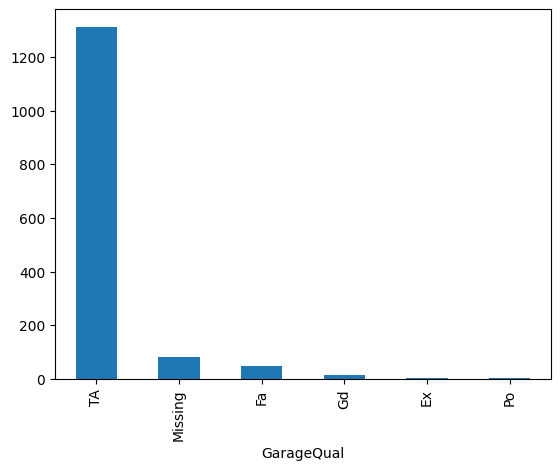

In [42]:
df['GarageQual'].value_counts().plot.bar()
plt.show()

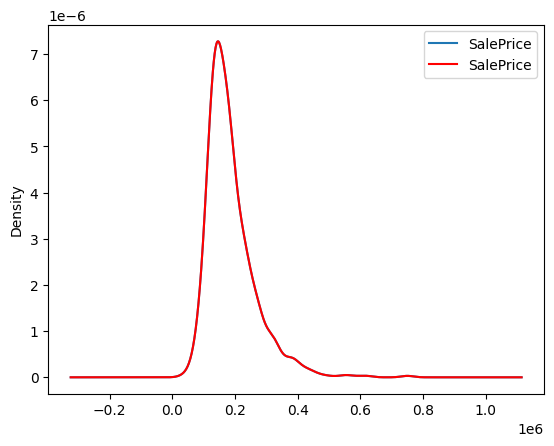

In [43]:
fig = plt.figure()
ax = fig.add_subplot()

temp.plot(kind='kde', ax=ax)
df.loc[df['GarageQual'] == 'TA', 'SalePrice'].plot.density(ax=ax, color='red')

plt.legend()
plt.show()

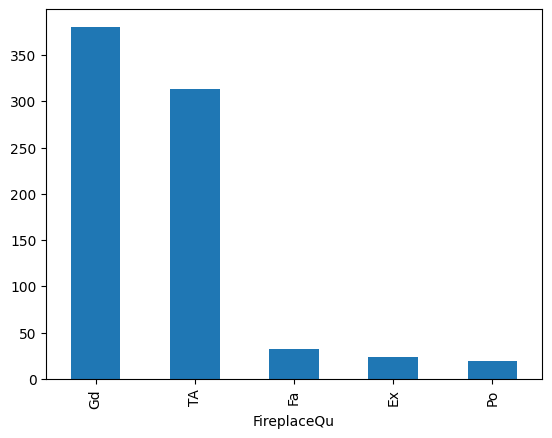

In [44]:
df['FireplaceQu'].value_counts().plot.bar()
plt.show()

In [45]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

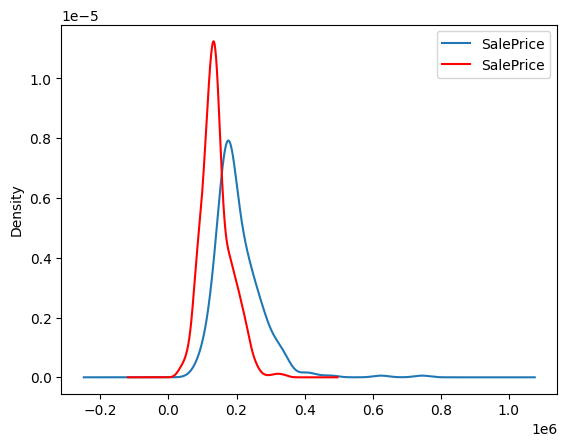

In [46]:
df.loc[df['FireplaceQu'] == 'TA', 'SalePrice'].plot.density()
df.loc[df['FireplaceQu'].isnull(), 'SalePrice'].plot.density(color='red')
plt.legend()
plt.show()

In [47]:
temp = df.loc[df['FireplaceQu'] == 'TA', 'SalePrice']

In [48]:
df['FireplaceQu'].fillna('TA', inplace=True)

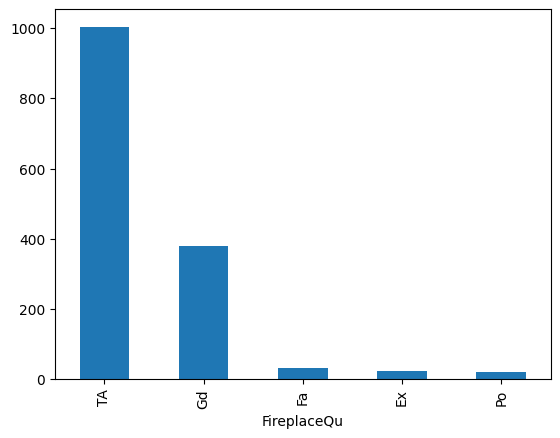

In [49]:
df['FireplaceQu'].value_counts().plot.bar()
plt.show()

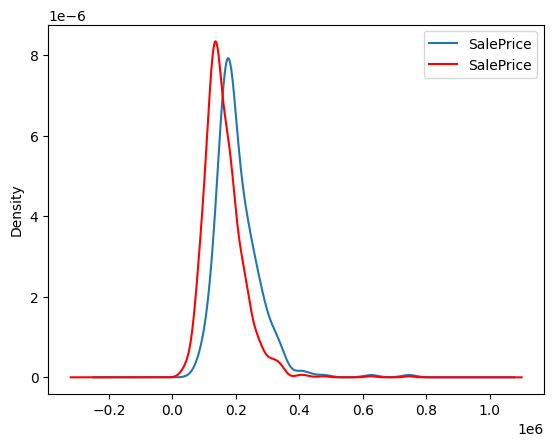

In [50]:
fig = plt.figure()
ax = fig.add_subplot()

temp.plot(kind='kde', ax=ax)
df.loc[df['FireplaceQu'] == 'TA', 'SalePrice'].plot.density(ax=ax, color='red')

plt.legend()
plt.show()

In [51]:
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

In [52]:
X, y = df.iloc[:,:-1], df.iloc[:,-1]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
imputer = SimpleImputer(strategy='constant', fill_value='Missing')

In [55]:
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [56]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)